# exp01–04 training analysis — what went wrong, and what it means for exp05

Post-hoc analysis of the four GRPO runs (W&B project `brighton_zz-uc-san-diego/huggingface`),
built 2026-08-02 to inform the exp05 config.

| exp | W&B name | W&B id | script | outcome |
|-----|----------|--------|--------|---------|
| exp01 | hardy-river-3 | `vs89r50o` | `train_grpo.py` (v1, Qwen2.5-7B) | finished, 1,000 steps |
| exp02 | true-darkness-4 | `h0va9zlw` | `train_grpo_v3.py` (v3, Qwen3-8B) | **failed**, killed @ step ~130 |
| exp03 | drawn-meadow-5 | `jwcpfh4t` | `train_grpo_v3.py` (v3) | killed @ step ~730 |
| exp04 | fiery-firebrand-6 | `cjteb9re` | `train_grpo_v4.py` (v4) | killed @ step ~5,220 → `checkpoint-5000` |

**Caveats, read before interpreting:**

1. **Reward values are not comparable across generations** (ADR 0002) — each
   dataset generation redefines the reward scale. Cross-run comparison is only valid
   for scale-free metrics: entropy, completion length, `frac_reward_zero_std`,
   clip ratios.
2. The qualitative text samples analyzed at the end come from the **published GGUF
   (built from the lost `checkpoint-3000`, Q4_K_M-quantized), collected during Lizzie
   play** — they reflect the *deployed* model at step 3000, not exp04's final state
   (`checkpoint-5000`, never merged or played).
3. All rollout logs were destroyed in the 2026-05-06 incident, so token-level
   claims about what the model generated *during* training cannot be verified —
   only the aggregate W&B metrics survive.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

DATA = Path("data") if Path("data").exists() else Path("notebooks/data")

# -- palette (validated: 4 slots pass CVD + normal-vision floors on light surface;
#    aqua/yellow are sub-3:1 contrast -> always paired with direct labels)
C = {"exp04": "#2a78d6", "exp01": "#eb6834", "exp02": "#1baf7a", "exp03": "#eda100"}
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SURFACE = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "figure.titlesize": 13,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

RUNS = {"exp01": "hardy-river-3", "exp02": "true-darkness-4",
        "exp03": "drawn-meadow-5", "exp04": "fiery-firebrand-6"}

def load(exp):
    """Load one run's history, collapsed onto trainer global_step."""
    f = next(DATA.glob(f"{exp}_*.parquet"))
    df = pd.read_parquet(f).dropna(subset=["train/global_step"])
    df = (df.groupby("train/global_step").mean(numeric_only=True).reset_index()
            .sort_values("train/global_step")
            .rename(columns=lambda c: c.replace("train/", "")))
    return df

H = {e: load(e) for e in RUNS}
CFG = json.loads((DATA / "run_configs.json").read_text())
{e: len(H[e]) for e in H}

{'exp01': 101, 'exp02': 14, 'exp03': 74, 'exp04': 523}

> **Re-pulling from W&B** (only needed if `data/*.parquet` is missing): run
> `python notebooks/pull_wandb_histories.py` from the repo root — it scans full
> histories for the four runs and rewrites the parquet cache. Requires `~/.netrc`
> W&B credentials.

## 0. Config diff — what actually changed between runs

Reward-stack changes are documented in `CLAUDE.md`/ADR 0002. The optimizer/sampling
side is where the unexamined problems live. Sampling params (`temperature=1.0`,
`top_p=1.0`), `beta=0` (no KL), `loss_type='dapo'`, `scale_rewards='group'` were
**TRL defaults in every run — never consciously chosen.**

In [2]:
keys = ["learning_rate", "lr_scheduler_type", "warmup_ratio", "max_steps",
        "per_device_train_batch_size", "gradient_accumulation_steps", "num_generations",
        "max_completion_length", "temperature", "top_p", "beta", "epsilon",
        "loss_type", "scale_rewards", "use_vllm"]
pd.DataFrame({e: {k: CFG[e].get(k) for k in keys} for e in RUNS})

,exp01,exp02,exp03,exp04
learning_rate,0.000005,0.000005,0.000005,0.000005
lr_scheduler_type,cosine,constant_with_warmup,constant_with_warmup,constant_with_warmup
warmup_ratio,0.1,0.02,0.02,0.02
max_steps,1000,270000,270000,270000
per_device_train_batch_size,8,8,16,16
gradient_accumulation_steps,2,2,4,4
num_generations,8,8,8,8
max_completion_length,1024,512,1024,512
temperature,1,1,1,1
top_p,1,1,1,1


Two structural consequences fall straight out of this table:

- **`max_steps=270000`** (= the row count of the v3 dataset, intended as a manual-stop
  safety ceiling) silently defines `warmup_ratio × max_steps = 5,400 warmup steps`.
  exp04 stopped at 5,220 — **the entire run happened inside LR warmup** (§2).
- **Effective batch**: exp04 optimizes 16 × 4 = 64 completions/optimizer-step = 8
  prompts × 8 generations. The group-relative advantage therefore rests on 8 samples
  per prompt — small groups make ties likely (§4).

## 1. Reward overview — four runs at a glance

Each panel has its **own y-scale** (rewards are not cross-comparable). Thin line =
raw logged reward (every 10 steps), heavy line = centered rolling mean.

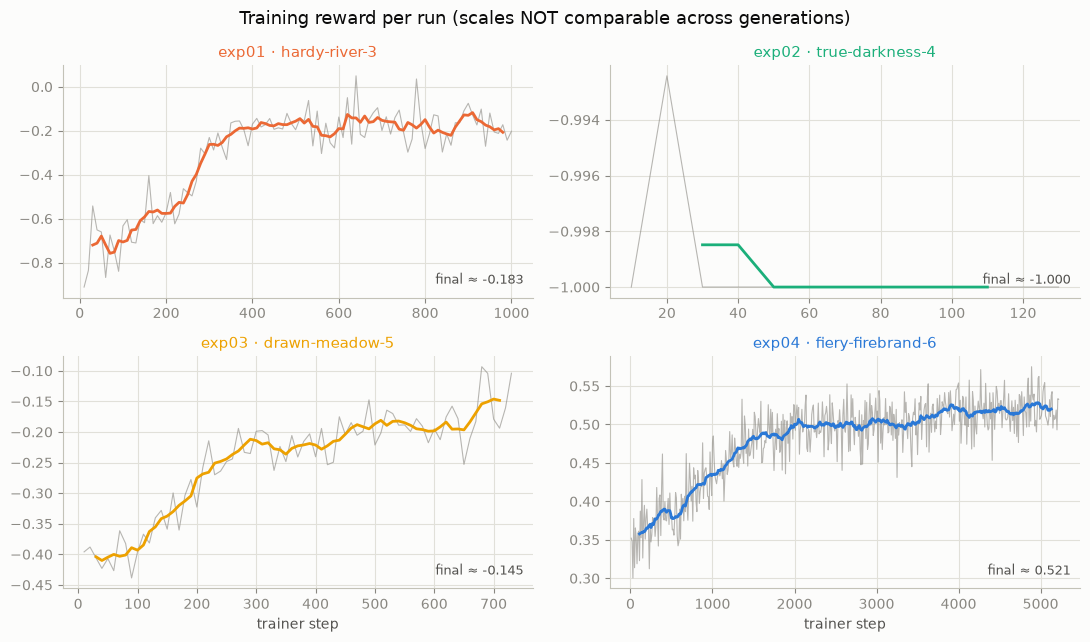

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
fig.suptitle("Training reward per run (scales NOT comparable across generations)")
for ax, exp in zip(axes.flat, RUNS):
    df, name = H[exp], RUNS[exp]
    s, r = df["global_step"], df["reward"]
    w = max(5, len(df) // 25)
    ax.plot(s, r, color=MUTED, lw=0.8, alpha=0.6)
    ax.plot(s, r.rolling(w, center=True).mean(), color=C[exp])
    ax.set_title(f"{exp} · {name}", color=C[exp])
    ax.text(0.98, 0.06, f"final ≈ {r.iloc[-max(1, len(r)//10):].mean():.3f}",
            transform=ax.transAxes, ha="right", color=INK2, fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("trainer step")
fig.tight_layout()

### 1a. exp02 post-mortem: the truncation catastrophe

exp02 (`true-darkness-4`) is not a "weak run" — it is a **structurally dead** one, and
the metrics prove the mechanism. `max_completion_length=512` with Qwen3's native
thinking mode still enabled meant every completion filled the whole budget with
`<think>` text and was truncated before ever emitting `MOVE:`:

- `completions/clipped_ratio ≈ 1.0` — every generation truncated at 512 tokens,
- gate reward pinned at **−1.0** (no `MOVE:` found) for every sample,
- identical rewards in every group → `frac_reward_zero_std = 1.0` → advantage = 0
  → **`grad_norm = 0.0`: the model never received a single gradient.**

This is the empirical basis of ADR 0003 (`enable_thinking=False` everywhere), and it is
also the earliest live demonstration of the zero-variance failure mode that returns —
in milder form — inside exp04 (§4). exp03 "fixed" it by doubling
`max_completion_length` to 1024; v4 fixed the actual cause and reclaimed 512.

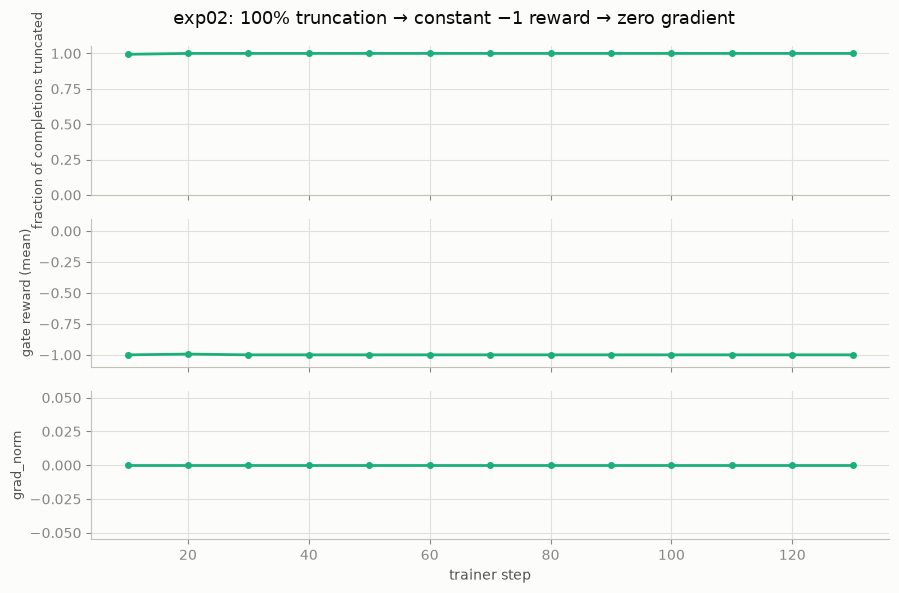

In [4]:
df = H["exp02"]
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
fig.suptitle("exp02: 100% truncation → constant −1 reward → zero gradient")
panels = [("completions/clipped_ratio", "fraction of completions truncated", (0, 1.05)),
          ("rewards/format_and_legality_reward_func/mean", "gate reward (mean)", (-1.1, 0.1)),
          ("grad_norm", "grad_norm", None)]
for ax, (col, label, ylim) in zip(axes, panels):
    ax.plot(df["global_step"], df[col], color=C["exp02"], marker="o", ms=4)
    ax.set_ylabel(label, fontsize=9)
    if ylim: ax.set_ylim(*ylim)
axes[-1].set_xlabel("trainer step")
fig.tight_layout()

## 2. exp04 finding #1 — the whole run happened inside LR warmup

`warmup_ratio=0.02 × max_steps=270,000` ⇒ warmup ends at step **5,400**. The run was
killed at ~5,220, LR ≈ 4.8e-06 — the configured `constant_with_warmup` plateau at
5e-06 was **never reached**. Every observation about exp04 (including "it converged
around step 3000") describes a model trained on a *ramping* LR that averaged ~2.4e-06.

Two readings, which the curve alone cannot distinguish:

- *Optimistic*: the model plateaued despite the LR still rising — more LR would not help.
- *Skeptical*: early training (where most learning happened) ran at 0.1–1e-06, an
  order of magnitude below intent; the schedule, not the model, set the pace.

Either way, exp05 must make warmup a deliberate choice: pin `max_steps` to the real
planned horizon (or set `warmup_steps` explicitly) so `warmup_ratio` stops being a
function of an arbitrary safety ceiling.

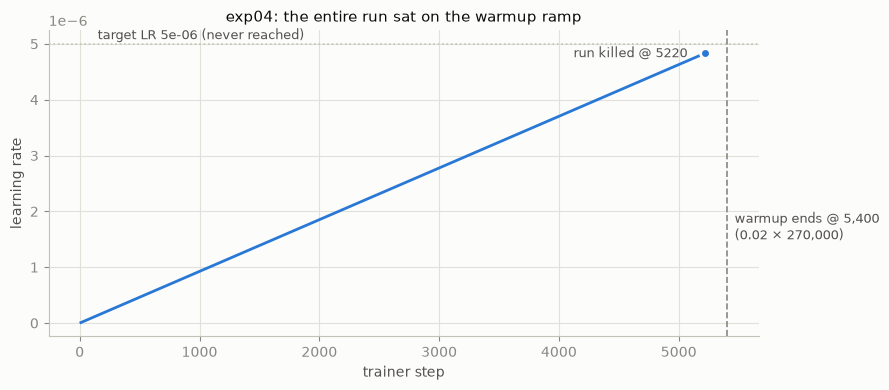

In [5]:
df = H["exp04"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df["global_step"], df["learning_rate"], color=C["exp04"])
ax.axhline(5e-6, color=BASE, ls=":", lw=1.2)
ax.text(150, 5.03e-6, "target LR 5e-06 (never reached)", color=INK2, fontsize=9, va="bottom")
ax.axvline(5400, color=MUTED, ls="--", lw=1.2)
ax.text(5400, 1.5e-6, "  warmup ends @ 5,400\n  (0.02 × 270,000)", color=INK2, fontsize=9)
end = df["global_step"].iloc[-1]
ax.plot([end], [df["learning_rate"].iloc[-1]], "o", color=C["exp04"], ms=7,
        mec=SURFACE, mew=2)
ax.text(end - 80, df["learning_rate"].iloc[-1], f"run killed @ {end:.0f}  ",
        ha="right", va="center", color=INK2, fontsize=9)
ax.set_xlabel("trainer step"); ax.set_ylabel("learning rate")
ax.set_title("exp04: the entire run sat on the warmup ramp")
fig.tight_layout()

## 3. exp04 finding #2 — reward: real early gains, then an oscillating plateau

The rolling mean rises 0.37 → 0.50 in the first ~2,000 steps, then gains ≈0.02 over the
next 3,200 steps — **~37 GPU-hours for noise-level improvement**. The visible
"oscillation" decomposes into two parts:

1. **Sampling noise floor** — each logged point averages 64 completions drawn at
   `temperature=1.0` from a stochastic policy against a bounded reward; a rolling std of
   ±0.02–0.03 around the mean is irreducible at this batch size.
2. **The plateau itself** — after ~step 3,000 the trend is flat, so *all* remaining
   movement is noise, which reads visually as "severe oscillation".

The honest summary is not "oscillation is a problem to smooth away" but "the signal
stopped improving while its variance stayed constant". exp05 levers: bigger effective
batch or more generations (lowers the noise floor), and a reward with fewer ties
(raises the ceiling, §4).

mean rolling std (noise floor): 0.0237
reward gain 0→2000:  +0.1398
reward gain 2000→5200: +0.0222


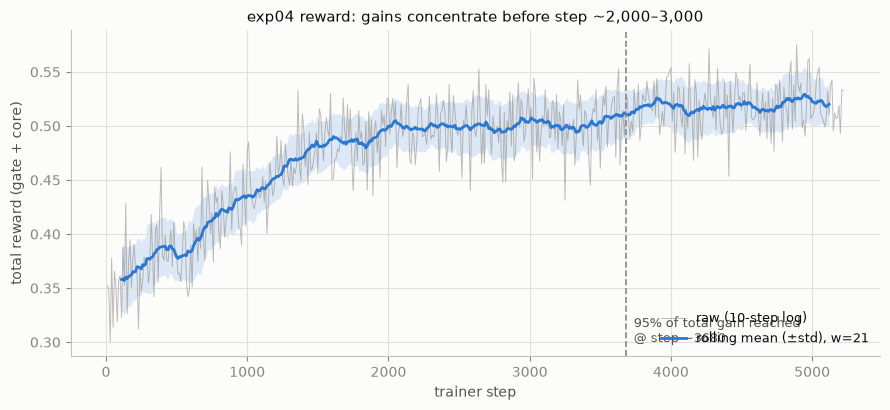

In [6]:
df = H["exp04"]
s, r = df["global_step"], df["reward"]
w = 21
rm, rs = r.rolling(w, center=True).mean(), r.rolling(w, center=True).std()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(s, r, color=MUTED, lw=0.7, alpha=0.55, label="raw (10-step log)")
ax.fill_between(s, rm - rs, rm + rs, color=C["exp04"], alpha=0.15, lw=0)
ax.plot(s, rm, color=C["exp04"], label=f"rolling mean (±std), w={w}")
conv = 3680
ax.axvline(conv, color=MUTED, ls="--", lw=1.2)
ax.text(conv, 0.30, f"  95% of total gain reached\n  @ step ~{conv}", color=INK2, fontsize=9)
ax.set_xlabel("trainer step"); ax.set_ylabel("total reward (gate + core)")
ax.set_title("exp04 reward: gains concentrate before step ~2,000–3,000")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
print(f"mean rolling std (noise floor): {rs.mean():.4f}")
print(f"reward gain 0→2000:  {rm[s.between(1900,2100)].mean() - rm.dropna().iloc[0]:+.4f}")
print(f"reward gain 2000→5200: {rm.dropna().iloc[-1] - rm[s.between(1900,2100)].mean():+.4f}")

## 4. exp04 finding #3 — the length/entropy collapse is one process, not two

Between steps ~2,500 and 4,500 mean completion length fell **90 → 43 tokens** and
token entropy fell **0.55 → 0.33**; their correlation over the run is **0.93**. The v4
reward contains no term that values the `REASONING:` text (v1's
`thinking_quality_reward_func` was dropped in v3/v4), so the shortest completion that
clears the gate and names a decent move is *reward-optimal by construction* — the
model is correctly optimizing what was specified: reasoning is cost, not asset.

This is the quantitative twin of the qualitative complaint (§7): templated,
move-irrelevant reasoning **is** what a length-collapsed, low-entropy policy looks like
in text form. Entropy collapse is also self-reinforcing in GRPO: a lower-entropy policy
produces more identical completions per group → more zero-variance groups (§5) → less
gradient — the run partially strangles its own learning signal.

corr(mean_length, entropy) = 0.928


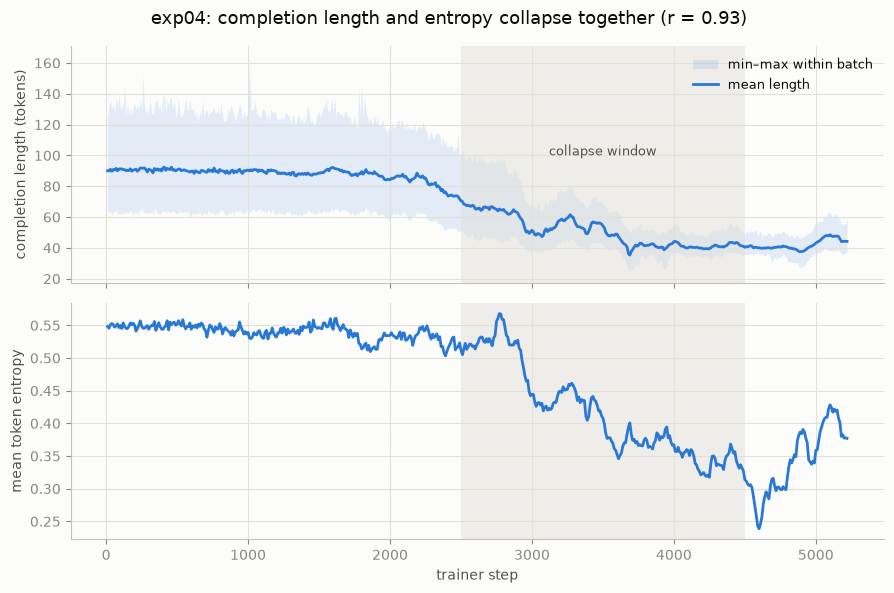

In [7]:
df = H["exp04"]
s = df["global_step"]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle("exp04: completion length and entropy collapse together (r = 0.93)")
ax = axes[0]
ax.fill_between(s, df["completions/min_length"], df["completions/max_length"],
                color=C["exp04"], alpha=0.12, lw=0, label="min–max within batch")
ax.plot(s, df["completions/mean_length"], color=C["exp04"], label="mean length")
ax.set_ylabel("completion length (tokens)")
ax.legend(loc="upper right", fontsize=9)
ax = axes[1]
ax.plot(s, df["entropy"], color=C["exp04"])
ax.set_ylabel("mean token entropy")
ax.set_xlabel("trainer step")
for a, y in [(axes[0], 95), (axes[1], 0.555)]:
    a.axvspan(2500, 4500, color=GRID, alpha=0.5, lw=0)
axes[0].text(3500, 100, "collapse window", ha="center", color=INK2, fontsize=9)
fig.tight_layout()
print("corr(mean_length, entropy) =",
      round(df["completions/mean_length"].corr(df["entropy"]), 3))

## 5. exp04 finding #4 — up to 61% of groups produced zero gradient

`frac_reward_zero_std` = fraction of prompt-groups whose 8 generations all got the
*same* reward. In GRPO the advantage is reward minus group mean (scaled by group std) —
an all-tied group has advantage 0 for every token: **compute fully spent, gradient
exactly zero.** The fraction climbed from ~1% to a peak of **61%** around step 3,500.

Why ties happen here, in order of importance:
1. **Same move ⇒ same reward.** The core reward depends only on the extracted `MOVE:`.
   As the policy sharpens (entropy ↓), all 8 generations increasingly pick the same
   coordinate — different reasoning text, identical reward.
2. **The gate saturated** (§6): its −1/−0.5 spread disappeared once the model learned
   legality, removing the other source of within-group variance.
3. **Reward granularity.** In sparsely-evaluated positions the rank/policy composite
   takes few distinct values, so even *different* moves can tie.

The late-run dip (0.61 → ~0.30) coincides with rising LR and is not obviously
recovery — it tracks the noisy plateau. exp05 levers: sampling temperature > 1 /
diversity, dynamic resampling of zero-std groups (DAPO-style), larger
`num_generations`, and reward terms that vary *within* a same-move group (e.g.
reasoning-dependent terms).

run-averaged zero-std fraction: 29.4% of all groups → ~18 of ~60 GPU-hours generated completions that produced no gradient


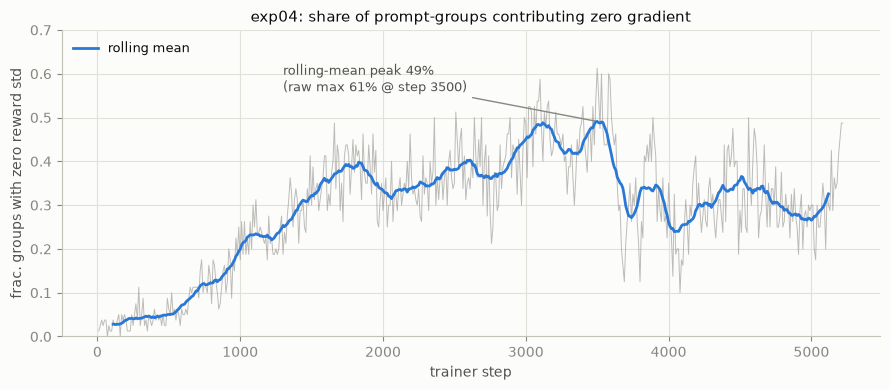

In [8]:
df = H["exp04"]
s, z = df["global_step"], df["frac_reward_zero_std"]
w = 21
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(s, z, color=MUTED, lw=0.7, alpha=0.55)
ax.plot(s, z.rolling(w, center=True).mean(), color=C["exp04"], label="rolling mean")
zm = z.rolling(w, center=True).mean()
pk = zm.idxmax()
ax.annotate(f"rolling-mean peak {zm.max():.0%}\n(raw max {z.max():.0%} @ step {s.loc[z.idxmax()]:.0f})",
            xy=(s.loc[pk], zm.max()),
            xytext=(s.loc[pk] - 2200, 0.56), color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax.set_ylim(0, 0.7)
ax.set_xlabel("trainer step"); ax.set_ylabel("frac. groups with zero reward std")
ax.set_title("exp04: share of prompt-groups contributing zero gradient")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
zs = df[["global_step", "frac_reward_zero_std"]].dropna()
frac = np.trapezoid(zs["frac_reward_zero_std"], zs["global_step"]) /        (zs["global_step"].iloc[-1] - zs["global_step"].iloc[0])
print(f"run-averaged zero-std fraction: {frac:.1%} of all groups → "
      f"~{frac * 60:.0f} of ~60 GPU-hours generated completions that produced no gradient")

## 6. exp04 finding #5 — the gate died on schedule; exploration died with it

Three shared-x panels tell one story:

- **Gate reward** hits exactly 0.0000 for the first time at step ~2,070 and stays
  saturated (legality/format fully learned — *success*, but from there on the gate term
  is dead weight in the reward sum and contributes no within-group variance).
- **`reward_std`** (mean within-group std) declines 0.35 → 0.24 — groups are getting
  more homogeneous, consistent with §5.
- **`grad_norm`** *rises* 0.2 → 0.7 (peak 1.05) as the LR ramps up on an
  ever-narrower policy — larger and larger steps on less and less diverse data. Not
  divergence, but the opposite of the "anneal as you converge" regime cosine/decay
  schedules encode.

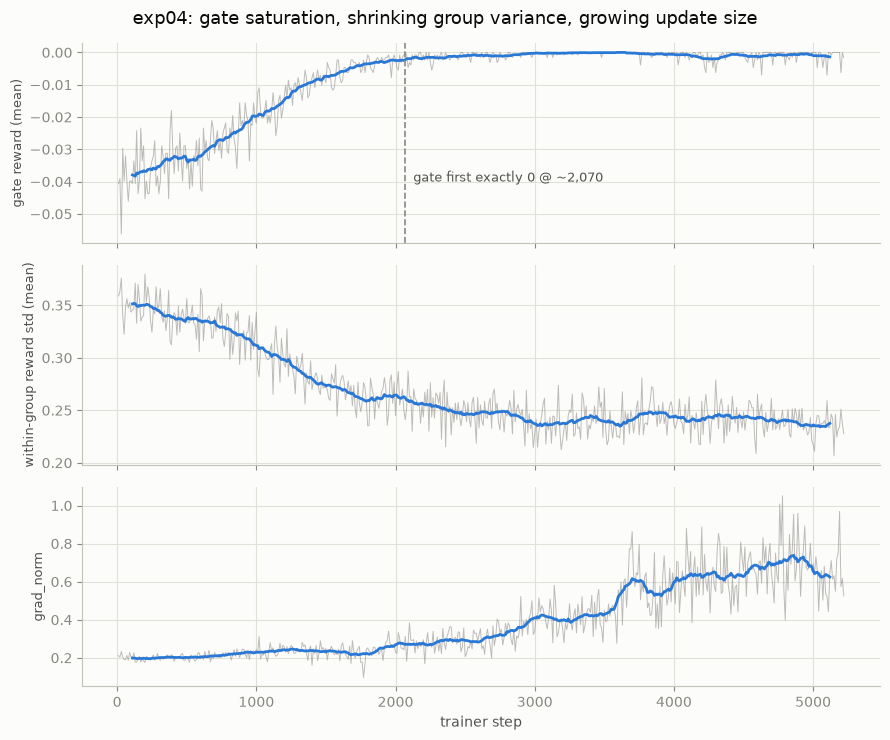

In [9]:
df = H["exp04"]
s = df["global_step"]
w = 21
fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
panels = [("rewards/format_and_legality_reward_func/mean", "gate reward (mean)"),
          ("reward_std", "within-group reward std (mean)"),
          ("grad_norm", "grad_norm")]
for ax, (col, label) in zip(axes, panels):
    ax.plot(s, df[col], color=MUTED, lw=0.7, alpha=0.55)
    ax.plot(s, df[col].rolling(w, center=True).mean(), color=C["exp04"])
    ax.set_ylabel(label, fontsize=9)
axes[0].axvline(2070, color=MUTED, ls="--", lw=1.2)
axes[0].text(2070, -0.04, "  gate first exactly 0 @ ~2,070", color=INK2, fontsize=9)
axes[-1].set_xlabel("trainer step")
fig.suptitle("exp04: gate saturation, shrinking group variance, growing update size")
fig.tight_layout()

## 7. Cross-run comparison — the scale-free metrics

Rewards are incomparable across generations, but entropy, length, and zero-std share
units. Two things stand out: **every healthy run loses entropy monotonically with no
mechanism pushing back** (no KL anchor — `beta=0`; no entropy bonus; greedy-ish reward),
and exp01 — whose reward *did* include a thinking-quality/length term — held length far
better than exp04, which had no such term. (exp01's late-run entropy drop coincides
with its cosine LR decaying to ~0, freezing the policy.)

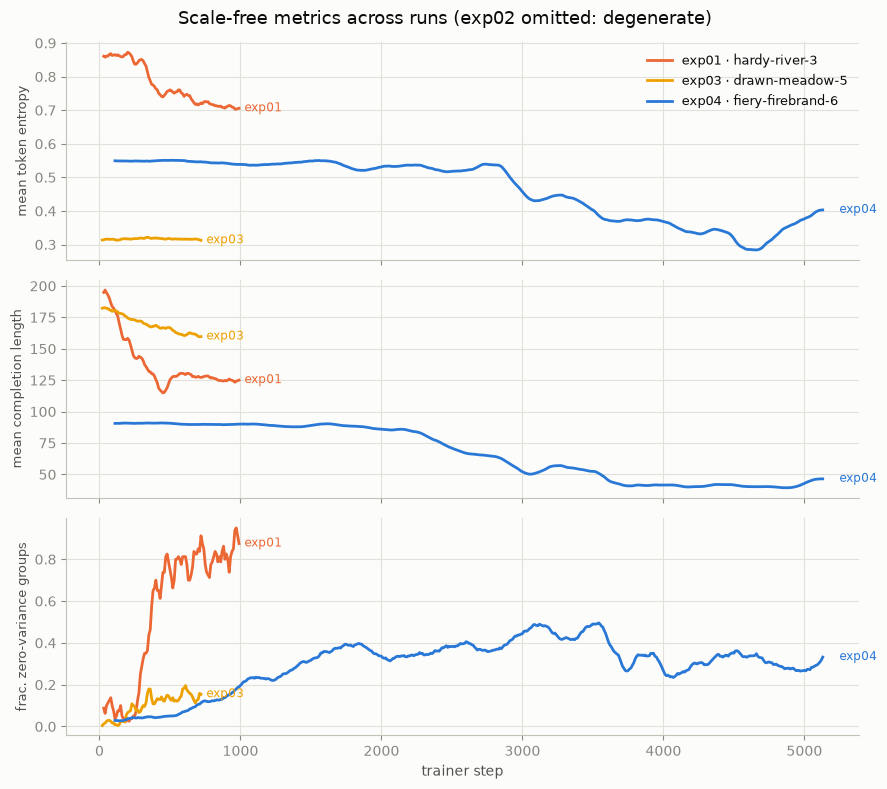

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
fig.suptitle("Scale-free metrics across runs (exp02 omitted: degenerate)")
metrics = [("entropy", "mean token entropy"),
           ("completions/mean_length", "mean completion length"),
           ("frac_reward_zero_std", "frac. zero-variance groups")]
show = ["exp01", "exp03", "exp04"]
for ax, (col, label) in zip(axes, metrics):
    for exp in show:
        df = H[exp]
        w = max(3, len(df) // 25)
        ax.plot(df["global_step"], df[col].rolling(w, center=True).mean(),
                color=C[exp], label=f"{exp} · {RUNS[exp]}")
        last = df[col].rolling(w, center=True).mean().dropna()
        if len(last):
            ax.text(df["global_step"].iloc[-1], last.iloc[-1], f" {exp}",
                    color=C[exp], fontsize=8.5, va="center")
    ax.set_ylabel(label, fontsize=9)
axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("trainer step")
fig.tight_layout()

## 8. Qualitative: what the deployed model actually says

Nine consecutive `REASONING`/`MOVE` outputs collected from the published GGUF
(`checkpoint-3000`, Q4_K_M) during a Lizzie game — `data/model_text_output_ckpt3000_gguf.txt`.
Three measurable problems:

1. **Template homogeneity** — the same stage-indexed stock phrases recur across
   unrelated positions ("The board shows a balanced position…", "help control the
   center", "White's recent moves have focused on securing the center…").
2. **Reasoning↔move disconnect** — the reasoning is generic enough that in most
   samples it would justify *any* nearby move; in 2/9 samples the chosen coordinate is
   never even mentioned in the reasoning.
3. **Factual board errors** — e.g. one sample claims a "complex middle game with both
   sides having several groups" on a ~7-stone board; another proposes a move
   "threatening Black's group around E2 and C3" in a game where reconstruction from the
   move history shows no such group. (With only 9 samples this is indicative, not
   statistical.)

None of this is surprising given §4: the reward never reads the reasoning, so the
reasoning converged to cheap boilerplate that survives the format gate.

In [11]:
import re
from collections import Counter
from itertools import combinations

raw = (DATA / "model_text_output_ckpt3000_gguf.txt").read_text()
samples = []
for block in raw.split("---"):
    m = re.search(r"REASONING:\s*(.+?)\s*MOVE:\s*([A-HJ][1-9]|PASS)", block, re.S)
    if m:
        samples.append({"reasoning": m.group(1).strip(), "move": m.group(2)})
print(f"{len(samples)} samples parsed\n")

TEMPLATES = ["board is largely empty", "board is completely empty",
             "balanced position", "complex middle game", "control the center",
             "central influence", "recent moves have focused on securing",
             "both black and white having", "both sides having", "help secure",
             "territorial"]
rows = []
for i, sm in enumerate(samples, 1):
    txt = sm["reasoning"].lower()
    hits = [t for t in TEMPLATES if t in txt]
    rows.append({"#": i, "move": sm["move"],
                 "move in reasoning": sm["move"].lower() in txt,
                 "words": len(sm["reasoning"].split()),
                 "template phrases hit": len(hits)})
disp = pd.DataFrame(rows).set_index("#")

# lexical diversity across samples
def bigrams(t):
    ws = re.findall(r"[a-z']+", t.lower())
    return set(zip(ws, ws[1:]))
jac = [len(bigrams(a["reasoning"]) & bigrams(b["reasoning"])) /
       len(bigrams(a["reasoning"]) | bigrams(b["reasoning"]))
       for a, b in combinations(samples, 2)]
allw = [w for sm in samples for w in re.findall(r"[a-z']+", sm["reasoning"].lower())]
allb = [b for sm in samples for b in zip(re.findall(r"[a-z']+", sm["reasoning"].lower()),
                                          re.findall(r"[a-z']+", sm["reasoning"].lower())[1:])]
print(f"distinct-1 (unique words / words):    {len(set(allw))/len(allw):.2f}")
print(f"distinct-2 (unique bigrams / bigrams): {len(set(allb))/len(allb):.2f}")
print(f"mean pairwise bigram Jaccard overlap:  {np.mean(jac):.2f}  (0 = all different, 1 = identical)")
print(f"move mentioned in its own reasoning:   {disp['move in reasoning'].sum()}/{len(disp)}")
disp

9 samples parsed

distinct-1 (unique words / words):    0.30
distinct-2 (unique bigrams / bigrams): 0.63
mean pairwise bigram Jaccard overlap:  0.12  (0 = all different, 1 = identical)
move mentioned in its own reasoning:   7/9


,move,move in reasoning,words,template phrases hit
#,,,,
1,D7,False,51,1
2,D4,True,60,2
3,E3,True,62,3
4,C5,True,45,4
5,D1,True,60,3
6,E5,True,59,6
7,J8,False,53,4
8,H5,True,67,3
9,E5,True,63,3


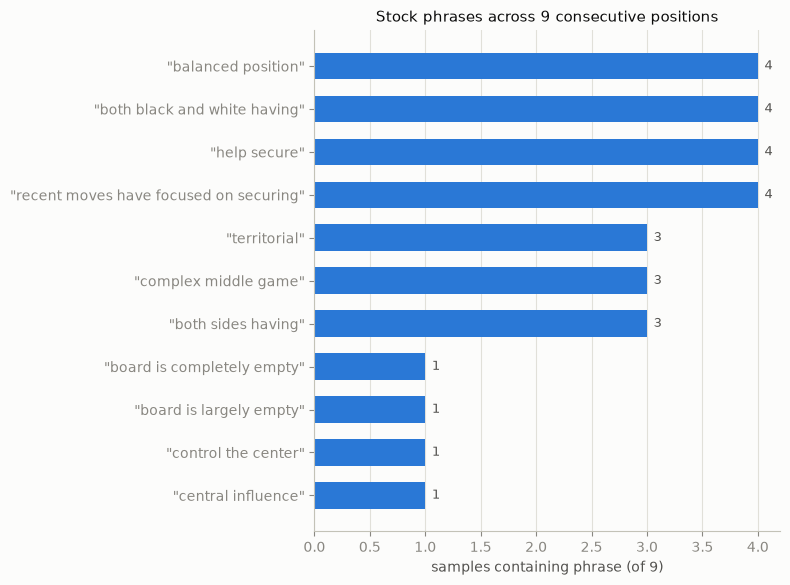

In [12]:
counts = Counter()
for sm in samples:
    txt = sm["reasoning"].lower()
    for t in TEMPLATES:
        if t in txt:
            counts[t] += 1
top = counts.most_common()
fig, ax = plt.subplots(figsize=(8, 0.45 * len(top) + 1))
ys = np.arange(len(top))
ax.barh(ys, [c for _, c in top], color=C["exp04"], height=0.62)
ax.set_yticks(ys, [f'"{t}"' for t, _ in top])
ax.invert_yaxis()
ax.set_xlabel(f"samples containing phrase (of {len(samples)})")
ax.set_title("Stock phrases across 9 consecutive positions")
for y, (_, c) in zip(ys, top):
    ax.text(c + 0.06, y, str(c), va="center", color=INK2, fontsize=9)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
fig.tight_layout()

## 9. Findings → exp05 levers

Ranked by expected impact. "Lever" is the *candidate* fix — the actual exp05 choices
are being decided separately (→ ADRs if adopted).

| # | Finding (evidence) | Root cause | Candidate exp05 lever |
|---|---|---|---|
| 1 | Whole run inside LR warmup; plateau LR never reached (§2) | `warmup_ratio` × safety-ceiling `max_steps` | Set real `max_steps`; explicit `warmup_steps`; pick schedule deliberately |
| 2 | Up to 61% zero-gradient groups, ~29% run-averaged (§5) | Same-move ties + gate saturation + low sampling diversity | Generation `temperature`↑, DAPO-style resampling / filtering, larger `num_generations`, tie-breaking reward terms |
| 3 | Length 90→43 & entropy 0.55→0.33, one process (§4) | Reward is move-only; reasoning is pure cost | Reasoning-aware reward term (length window / relevance / consistency), entropy-preserving loss knobs |
| 4 | Reasoning templated & move-irrelevant, 2/9 never mention the move; board-fact errors (§8) | Same as #3 — no gradient ever touches reasoning content | Same as #3, plus reasoning–move consistency check (v1's 言行一致 idea, reward_design.md) |
| 5 | Reward plateau after ~2k steps; ±0.02–0.03 noise floor (§3) | Signal exhausted at current diversity + reward granularity | Follows from #2/#3; bigger effective batch if affordable |
| 6 | Gate dead weight after step ~2,070 (§6) | Gate fully learned (a success) | Consider curriculum: drop/shrink gate weight once saturated, or keep as guardrail |
| 7 | `temperature=1.0, top_p=1.0, beta=0, loss_type='dapo', scale_rewards='group'` all defaults (§0) | Never consciously chosen | Make each an explicit decision in exp05 config |
| 8 | No held-out eval in any run | — | Fixed eval-position set + periodic KataGo match; W&B-logged |

**Provenance:** curves pulled 2026-08-02 via W&B API (`scan_history`, full fidelity)
and cached in `data/*.parquet`; configs in `data/run_configs.json`; text samples from
the deployed GGUF (see §8 caveat).